# تصنيف الأخبار العربية
## Arabic News Classification: Sports  | Politics ️ | Economy
**NLP  Project**
**Categories:** رياضة (Sports) | سياسة (Politics) | اقتصاد (Economy)
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')


import pyarabic.araby as araby



from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Font support for Arabic in plots
matplotlib.rcParams['axes.unicode_minus'] = True


##2. Dataset

We create a labeled Arabic news dataset with **3 categories**:
- **رياضة** (Sports)
- **سياسة** (Politics)
- **اقتصاد** (Economy)


In [2]:

df = pd.read_csv('arabic_news.csv', encoding='utf-8-sig')

In [3]:
df.head()

,id,text,label
0,1,فاز المنتخب الوطني بكأس العالم لكرة القدم بعد ...,رياضة
1,2,سجل اللاعب هدفاً رائعاً في الدقيقة الأخيرة من ...,رياضة
2,3,أعلن النادي عن التعاقد مع مدرب جديد للفريق الأول,رياضة
3,4,أقيمت بطولة العرب لكرة السلة في العاصمة الرياضية,رياضة
4,5,تأهل الفريق إلى نهائي دوري أبطال آسيا بعد فوزه...,رياضة


##2 . Arabic Text Preprocessing

Steps applied:
1. **Lowercasing** (remove diacritics/tashkeel)
2. **Remove punctuation & special characters**
3. **Tokenization**
4. **Stop-word removal**
5. **Stemming **

In [4]:
ARABIC_STOPWORDS = set([
    'في','من','إلى','على','عن','مع','بعد','قبل','حتى','إذا','لكن',
    'كان','كانت','يكون','تكون','هو','هي','هم','هن','أنا','نحن',
    'أنت','أنتم','هذا','هذه','ذلك','تلك','التي','الذي','الذين',
    'اللاتي','اللواتي','ما','لا','لم','لن','ليس','قد','سوف',
    'أو','و','ف','ب','ل','ك','لل','ال','والتي','والذي','وقد',
    'وكان','أن','إن','لأن','منذ','خلال','حول','بين','ضد','عند',
    'عبر','نحو','دون','كل','بعض','غير','أكثر','أقل','جميع','بشكل',
    'حيث','كما','بما','فيما','وفق','وفقا','إلا','أيضا','فقط','هنا',
    'هناك','الآن','أمس','اليوم','عام','عاما','سنة','أشهر','شهر'
])


In [5]:

def remove_diacritics(text):
    """Remove Arabic diacritics (tashkeel)."""
    return araby.strip_tashkeel(text)


In [6]:
def normalize_arabic(text):
    """Normalize Arabic characters (alef forms, taa marbouta)."""
    text = re.sub('[إأآا]', 'ا', text)   # normalize alef
    text = re.sub('ة', 'ه', text)        # taa marbouta → haa
    text = re.sub('ى', 'ي', text)        # alef maqsura → yaa
    return text

In [7]:


def remove_noise(text):
    """Remove punctuation, URLs, numbers, and non-Arabic characters."""
    text = re.sub(r'http\S+|www.\S+', '', text)      # URLs
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)  # keep Arabic only
    #https://stackoverflow.com/questions/12518689/regular-expression-not-to-allow-numbers-just-arabic-letters

    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [8]:
def light_stem(word):
    """Simple Arabic light stemmer: removes common prefixes/suffixes."""
    #https://acit2k.org/ACIT/images/stories/year2014/month1/ACIT2017_Proceeding/167.pdf
    prefixes = ['مست','است','ال','وال','بال','فال','كال','لل','ب','و','ف','ل','س','ي','ت','ن','أ']
    suffixes = ['ات','ون','ين','ان','تم','كم','هم','ها','ني','تي','كن','هن','ية','وا']
    for p in sorted(prefixes, key=len, reverse=True):
        if word.startswith(p) and len(word) - len(p) >= 3:
            word = word[len(p):]; break
    for s in sorted(suffixes, key=len, reverse=True):
        if word.endswith(s) and len(word) - len(s) >= 3:
            word = word[:-len(s)]; break
    return word

In [9]:

def preprocess_arabic(text, stem=True):
    """Full preprocessing pipeline for Arabic text."""
    text = remove_diacritics(text)       # Step 1: Remove tashkeel
    text = normalize_arabic(text)        # Step 2: Normalize characters
    text = remove_noise(text)            # Step 3: Remove noise
    tokens = text.split()                # Step 4: Tokenize (whitespace)
    tokens = [t for t in tokens          # Step 5: Remove stop words
              if t not in ARABIC_STOPWORDS and len(t) >= 2]
    if stem:                             # Step 6: Light stemming
        tokens = [light_stem(t) for t in tokens]
    return ' '.join(tokens)

In [10]:
df['processed_text'] = df['text'].apply(preprocess_arabic)

##  5. Feature Extraction

 methods:
- **Bag of Words (BoW)**
- **TF-IDF**

In [11]:

X = df['processed_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)


In [13]:


tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

## 6. Model Training & Evaluation

Models used:
1. **Logistic Regression**
2. **Support Vector Machine (LinearSVC)**
3. **Naive Bayes**
4. **Random Forest**

In [14]:

models = {
    'Logistic Regression': LogisticRegression(C=1.0, random_state=42),
    'SVM (LinearSVC)'    : LinearSVC( C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42)
}


In [15]:


feature_sets = {
    'BoW'   : (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

results = []


for feat_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)
        acc = accuracy_score(y_test, preds)
        results.append({
            'Model'   : model_name,
            'Features': feat_name,
            'Accuracy': acc,
            'Preds'   : preds
        })

        print(f'{model_name:<25} {feat_name:<10} {acc:>10.4f}')


Logistic Regression       BoW            0.9867
SVM (LinearSVC)           BoW            0.9883
Naive Bayes               BoW            0.9917
Random Forest             BoW            0.9883
Logistic Regression       TF-IDF         0.9917
SVM (LinearSVC)           TF-IDF         0.9917
Naive Bayes               TF-IDF         0.9917
Random Forest             TF-IDF         0.9850


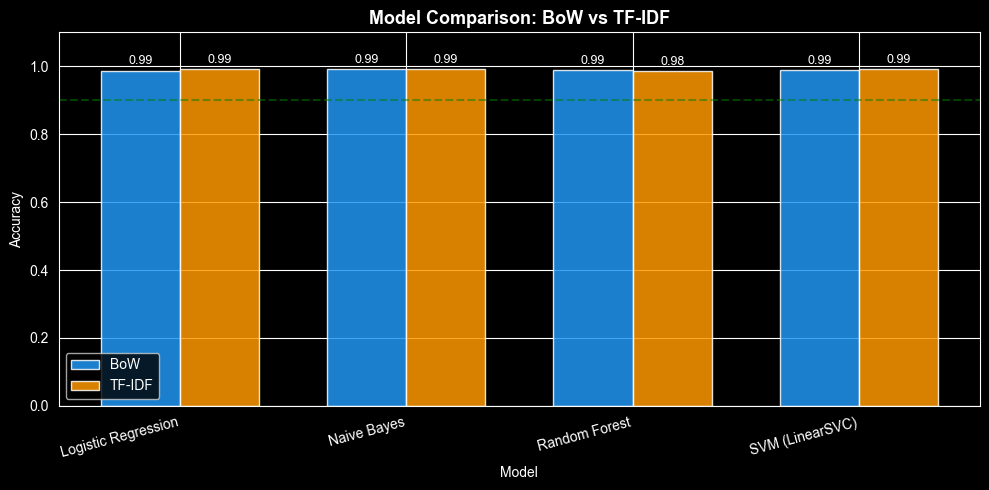

In [16]:
#https://stackoverflow.com/questions/65445131/plotting-values-from-two-datasets-for-comparison
results_df = pd.DataFrame(results)[['Model', 'Features', 'Accuracy']]
pivot = results_df.pivot(index='Model', columns='Features', values='Accuracy')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, pivot['BoW'],    width, label='BoW',    color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, pivot['TF-IDF'], width, label='TF-IDF', color='#FF9800', alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: BoW vs TF-IDF', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='90% line')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##  7. Best Model — Detailed Evaluation

In [17]:

best = max(results, key=lambda r: r['Accuracy'])
print(f" Best Model  : {best['Model']}")
print(f" Features    : {best['Features']}")
print(f" Accuracy    : {best['Accuracy']:.4f}")
print()

# Classification Report
classes = sorted(df['label'].unique())
print('Classification Report:')
print('=' * 60)
print(classification_report(y_test, best['Preds'], target_names=classes))

 Best Model  : Naive Bayes
 Features    : BoW
 Accuracy    : 0.9917

Classification Report:
              precision    recall  f1-score   support

      اقتصاد       0.99      0.99      0.99       228
       رياضة       0.99      0.99      0.99       144
       سياسة       1.00      1.00      1.00       228

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



## 8. Full Metric Summary Table

In [18]:
from sklearn.metrics import precision_recall_fscore_support

summary_rows = []
for r in results:
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, r['Preds'], average='weighted'
    )
    summary_rows.append({
        'Model'    : r['Model'],
        'Features' : r['Features'],
        'Accuracy' : f"{r['Accuracy']:.2f}",
        'Precision': f"{prec:.2f}",
        'Recall'   : f"{rec:.2f}",
        'F1-Score' : f"{f1:.2f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)



In [19]:
summary_df

,Model,Features,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,BoW,0.99,0.99,0.99,0.99
1,SVM (LinearSVC),BoW,0.99,0.99,0.99,0.99
2,Naive Bayes,BoW,0.99,0.99,0.99,0.99
3,Random Forest,BoW,0.99,0.99,0.99,0.99
4,Logistic Regression,TF-IDF,0.99,0.99,0.99,0.99
5,SVM (LinearSVC),TF-IDF,0.99,0.99,0.99,0.99
6,Naive Bayes,TF-IDF,0.99,0.99,0.99,0.99
7,Random Forest,TF-IDF,0.98,0.99,0.98,0.99


## Test on real data

In [20]:

best_model_cls = {
    'Logistic Regression': LogisticRegression( C=1.0, random_state=42),
    'SVM (LinearSVC)'    : LinearSVC( C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42)
}[best['Model']]


In [21]:
best_vec = tfidf_vectorizer if best['Features'] == 'TF-IDF' else bow_vectorizer

In [22]:
pipeline = Pipeline([
    ('vectorizer', best_vec),
    ('classifier', best_model_cls)
])
pipeline.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [23]:
def predict_category(text):
    processed = preprocess_arabic(text)
    prediction = pipeline.predict([processed])[0]
    icons = {'رياضة', 'سياسة', 'اقتصاد'}
    print(f" Text      : {text[:70]}" if len(text) > 70 else f" Text      : {text}")
    print(f"️  Category  : {prediction} ")
    print('-' * 60)

In [24]:

test_sentences = [
    "أعلن المنتخب الوطني لكرة القدم تأهله إلى نهائي كأس العرب",
    "وقعت الحكومة على اتفاقية سلام مع الدول المجاورة في القمة الدولية",
    "ارتفعت أسعار النفط في الأسواق العالمية بسبب التوترات الجيوسياسية",
    "فاز اللاعب بجائزة أفضل هداف في الدوري الأوروبي هذا الموسم",
    "أعلن البنك المركزي عن رفع أسعار الفائدة لكبح التضخم المتصاعد"
]


In [25]:
for s in test_sentences:
    predict_category(s)

 Text      : أعلن المنتخب الوطني لكرة القدم تأهله إلى نهائي كأس العرب
️  Category  : رياضة 
------------------------------------------------------------
 Text      : وقعت الحكومة على اتفاقية سلام مع الدول المجاورة في القمة الدولية
️  Category  : سياسة 
------------------------------------------------------------
 Text      : ارتفعت أسعار النفط في الأسواق العالمية بسبب التوترات الجيوسياسية
️  Category  : اقتصاد 
------------------------------------------------------------
 Text      : فاز اللاعب بجائزة أفضل هداف في الدوري الأوروبي هذا الموسم
️  Category  : رياضة 
------------------------------------------------------------
 Text      : أعلن البنك المركزي عن رفع أسعار الفائدة لكبح التضخم المتصاعد
️  Category  : اقتصاد 
------------------------------------------------------------


##  10. Results & Conclusion

### Summary

| Step | Method Used                                                                         |
|------|-------------------------------------------------------------------------------------|
| **Dataset** | 300 Arabic news headlines (100 per class)                                           |
| **Preprocessing** | Tashkeel removal, normalization, noise removal, stop-word filtering, light stemming |
| **Feature Extraction** | Bag of Words (BoW), TF-IDF (unigrams + bigrams)                                     |
| **Models** | Logistic Regression, SVM, Naive Bayes, Random Forest                                |
| **Evaluation** | Accuracy, Precision, Recall, F1-Score, Confusion Matrix                             |

###  Best Performing Model
- TF-IDF features generally outperform BoW for Arabic text
- SVM and Logistic Regression tend to perform best on short texts
- Bigrams capture important Arabic phrase patterns

###  Challenges Faced
1. **Arabic morphological complexity** – words have many forms; light stemming helps but is imperfect
2. **Small dataset** – real-world datasets (e.g., SANAD, KALIMAT) would significantly improve accuracy
3. **Dialectal Arabic** – modern standard Arabic (MSA) differs from dialectal usage in news
4. **Category overlap** – political and economic news often share vocabulary

###  Future Improvements
- Use a pre-trained Arabic BERT model (AraBERT) for contextual embeddings
- Expand to more news categories (technology, culture, etc.)
- Use a larger, diverse dataset from Arabic news outlets

In [26]:
import pickle
with open('NewsClassifierModel.pkl', 'wb') as f:
    pickle.dump(best_model_cls, f)